<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS05/JS05_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS05_03 — Klasifikasi SMS

## Persiapan

Jika library belum terpasang, hapus `#` pada baris `%pip` lalu jalankan.

In [1]:
# %pip install numpy pandas scikit-learn matplotlib seaborn

In [2]:
get_ipython().run_line_magic('matplotlib', 'inline')
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 110})
pd.set_option('display.max_columns', 25)
pd.set_option('display.precision', 4)

### Lokasi data

Ubah `DATA_DIR` jika CSV disimpan di folder lain.

In [3]:
DATA_DIR = Path('.')  # Ganti bila perlu, misalnya Path('/content')

def data_path(nama):
    kandidat = [
        DATA_DIR / nama, DATA_DIR / 'data' / nama,
        Path('/content') / nama, Path.home() / 'Downloads' / nama
    ]
    for lokasi in kandidat:
        if lokasi.is_file():
            return lokasi
    raise FileNotFoundError(
        f'{nama} tidak ditemukan. Letakkan CSV di folder notebook/data/ '
        'atau ubah DATA_DIR.'
    )

for nama in ['spam.csv']:
    lokasi = data_path(nama)
    print(f'{nama}: ditemukan ({lokasi.stat().st_size:,} byte)')

def evaluasi_model(model, X_train, X_test, y_train, y_test, nama, labels=None):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    hasil = {
        'Model': nama,
        'Akurasi train': accuracy_score(y_train, pred_train),
        'Akurasi test': accuracy_score(y_test, pred_test),
        'F1 makro': f1_score(y_test, pred_test, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_test, pred_test),
    }
    display(pd.DataFrame([hasil]).set_index('Model'))
    print(classification_report(y_test, pred_test, labels=labels, zero_division=0))
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred_test, labels=labels, cmap='Blues', colorbar=False, ax=ax
    )
    ax.set(title=nama, xlabel='Prediksi', ylabel='Label sebenarnya')
    plt.tight_layout()
    plt.show()
    return hasil

spam.csv: ditemukan (503,663 byte)


## Membaca data

Pakai kolom `v1` sebagai label dan `v2` sebagai isi SMS. Label diubah menjadi ham = 0 dan spam = 1.

In [4]:
spam_raw = pd.read_csv(data_path('spam.csv'), encoding='latin-1')
display(spam_raw.head())
spam_lab = spam_raw[['v1', 'v2']].rename(columns={'v1': 'Labels', 'v2': 'SMS'}).copy()
assert not spam_lab.isna().any().any()
assert set(spam_lab['Labels']) == {'ham', 'spam'}
spam_lab.info()
display(spam_lab.describe())
display(spam_lab['Labels'].value_counts().rename('Jumlah').to_frame())
print('Pesan duplikat eksak:', spam_lab.duplicated(subset='SMS').sum())
spam_lab['Labels'] = spam_lab['Labels'].map({'ham': 0, 'spam': 1})
display(spam_lab.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Labels  5572 non-null   object
 1   SMS     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,Labels,SMS
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


,Jumlah
Labels,
ham,4825
spam,747


Pesan duplikat eksak: 403


,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Menyiapkan fitur

Data dibagi 80% latih dan 20% uji. CountVectorizer menghitung kata dan mempelajari kosakata dari data latih.

Duplikat masih dipakai mengikuti modul; pada Tugas 2 duplikat dihapus.

In [5]:
spam_lab_X_train, spam_lab_X_test, spam_lab_y_train, spam_lab_y_test = train_test_split(
    spam_lab['SMS'], spam_lab['Labels'], test_size=0.20, random_state=50
)
spam_lab_bow = CountVectorizer()
spam_lab_train_counts = spam_lab_bow.fit_transform(spam_lab_X_train)
spam_lab_test_counts = spam_lab_bow.transform(spam_lab_X_test)
print('Kosakata:', len(spam_lab_bow.get_feature_names_out()))
print('Dimensi train:', spam_lab_train_counts.shape)
print('Dimensi test :', spam_lab_test_counts.shape)
print('Contoh token:', spam_lab_bow.get_feature_names_out()[:20])
spam_lab_overlap = set(spam_lab_X_train) & set(spam_lab_X_test)
print('Teks unik yang muncul di train dan test:', len(spam_lab_overlap))

Kosakata: 7727
Dimensi train: (4457, 7727)
Dimensi test : (1115, 7727)
Contoh token: ['00' '000' '000pes' '008704050406' '0089' '01223585334' '0125698789' '02'
 '0207' '02072069400' '02073162414' '021' '03' '04' '0430' '05' '050703'
 '0578' '06' '07']
Teks unik yang muncul di train dan test: 109


### Melatih dan menguji model

Gunakan MultinomialNB, lalu lihat akurasi, precision, recall, F1, dan confusion matrix.

,Akurasi train,Akurasi test,F1 makro,Balanced accuracy
Model,,,,
SMS — CountVectorizer + MultinomialNB,0.9946,0.9776,0.9523,0.9301


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       954
           1       0.98      0.86      0.92       161

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



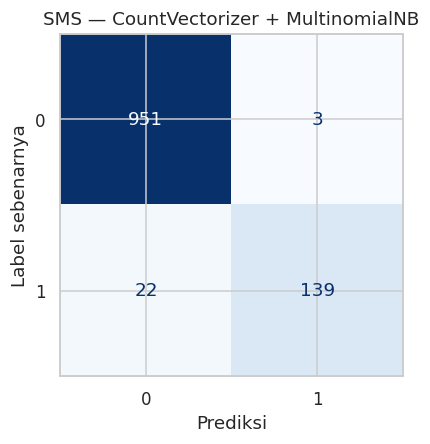

F1 kelas spam: 0.9174917491749175


**Kesimpulan:** akurasi latih 99.46% dan akurasi uji 97.76%. Ada 109 teks yang muncul di data latih dan uji; hal ini diperbaiki dengan menghapus duplikat pada Tugas 2.

In [6]:
spam_lab_model = MultinomialNB()
spam_lab_model.fit(spam_lab_train_counts, spam_lab_y_train)
spam_lab_hasil = evaluasi_model(
    spam_lab_model, spam_lab_train_counts, spam_lab_test_counts,
    spam_lab_y_train, spam_lab_y_test, 'SMS — CountVectorizer + MultinomialNB', labels=[0, 1]
)
spam_lab_pred = spam_lab_model.predict(spam_lab_test_counts)
print('F1 kelas spam:', f1_score(spam_lab_y_test, spam_lab_pred, zero_division=0))
display(Markdown(
    f"**Kesimpulan:** akurasi latih {spam_lab_hasil['Akurasi train']:.2%} "
    f"dan akurasi uji {spam_lab_hasil['Akurasi test']:.2%}. "
    f"Ada {len(spam_lab_overlap)} teks yang muncul di data latih dan uji; "
    "hal ini diperbaiki dengan menghapus duplikat pada Tugas 2."
))